# TSARA — how ingestion works

**Phase 3 walkthrough.** Run top to bottom. Every number and figure below is
produced by the package itself, from data manufactured in this notebook — no
real measurement is read anywhere, and nothing needs mounting to run it.

The archive TSARA was built for is not silent here, though. Most of this phase's
design decisions were settled by measuring real files, and where that happened
the measurement is quoted in the prose with a pointer to `docs/METHODS.md` §9,
which holds the tables. The *mechanism* each one taught is reproduced below at
miniature scale, where it can be checked against a known answer.

---

## The problem ingestion actually solves

A campaign archive is not a dataset. It is a few thousand files, written by
instruments that never agreed on anything: different sampling rates, different
column names for the same gas, different units, different missing-value
conventions, scattered across a directory tree whose layout encodes information
that appears nowhere inside the files. Some of it is comma-separated text, some
of it is NASA/NOAA ICARTT, some of it is parquet from a processing chain, and an
instrument's files routinely span more than one naming convention at once — a
mid-campaign reorganization, or an archive mirror sitting beside a local copy.

The tempting response is a script per instrument. That works exactly once, and
then a new campaign arrives.

TSARA's position is that **directory conventions, column names, units and
quality rules are data, not code** (CLAUDE.md §5). They belong in a YAML
manifest that describes the archive, and one code path reads any archive a
manifest can describe. What comes out is deliberately boring:

> one `xarray.Dataset` per instrument, on that instrument's own timestamps, in
> canonical units, QA/QC masked, carrying a resolved uncertainty budget and
> enough provenance to explain itself.

Nothing is resampled and nothing is aligned. That is Phase 4's job, and doing it
here would destroy information Phase 4 needs (`docs/METHODS.md` §1.1).

## How this notebook knows the right answer

The same way Phase 2 did: it manufactures the archive. `generate()` builds
streams whose true values are known exactly, `export_raw()` writes them out as
raw CSV plus a manifest describing those files, and `ingest_campaign()` reads
them back with no privileged knowledge of anything. Comparing the two is the
only check in the package that bears on whether ingestion is *correct* rather
than merely self-consistent (`docs/METHODS.md` §9.9).

In [1]:
import json
import logging
import tempfile
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from matplotlib.colors import LinearSegmentedColormap

from tsara import setup_logging
from tsara.config.loader import load_manifest
from tsara.config.manifest import CSVLoader, ICARTTLoader, Manifest
from tsara.ingest import (
    available_readers,
    compile_template,
    crawl,
    ingest_campaign,
    load_streams,
    read_file,
    save_streams,
)
from tsara.ingest.icartt import parse_icartt_header, read_icartt
from tsara.synthetic import generate
from tsara.synthetic.config import SyntheticConfig
from tsara.synthetic.export import RawUnits, export_raw

# --- figure style (identical to notebook 01, so the two read as one set) ----
# Categorical hues are used in a fixed order and never cycled; the sequential
# ramp is one hue light->dark. Grid and axes are hairlines a shade off the
# surface so the data is the only assertive thing on the page.
C1, C2, C3 = "#0072b2", "#e69f00", "#009e73"  # categorical slots 1, 2, 3
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
SEQ = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
# The lightest step vanishes against the page, so a track drawn on the surface
# itself starts one step in.
TRACK = LinearSegmentedColormap.from_list("tsara_track", SEQ[1:])

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "axes.edgecolor": "#c3c2b7",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "normal",
        "axes.titlelocation": "left",
        "axes.labelsize": 9.5,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "grid.color": GRID,
        "grid.linewidth": 0.7,
        "grid.linestyle": "-",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "font.size": 9.5,
        "lines.linewidth": 1.4,
        "figure.dpi": 110,
    }
)


def finish(
    ax, title=None, sub=None, ylab=None, xlab=None, legend=False, grid_axis="y", loc="upper right"
):
    """Apply the shared chrome: left-aligned title, muted subtitle, hairline grid."""
    if title:
        ax.set_title(title, pad=19 if sub else 8)
    if sub:
        ax.text(0, 1.025, sub, transform=ax.transAxes, fontsize=8.8, color=MUTED, va="bottom")
    if ylab:
        ax.set_ylabel(ylab)
    if xlab:
        ax.set_xlabel(xlab)
    if grid_axis:
        ax.grid(True, axis=grid_axis, alpha=0.9)
    ax.set_axisbelow(True)
    if legend:
        ax.legend(loc=loc)


def hhmm(ax, fmt="%H:%M"):
    """Label the x axis as clock time; the date belongs in the title."""
    ax.xaxis.set_major_formatter(mdates.DateFormatter(fmt))


def median_interval(stream):
    """Return a stream's median sampling interval in seconds."""
    gaps = np.diff(stream["time"].values).astype("timedelta64[ms]").astype(float)
    return float(np.median(gaps)) / 1000.0


def break_gaps(clock, values, tolerance=5.0):
    """Insert a NaN wherever the clock jumps, so no line is drawn across a gap.

    matplotlib rules a straight segment between consecutive points, so a record
    with a hole in it renders as a smooth ramp across the hole — an
    interpolation of exactly the kind TSARA refuses to perform on a gas. One
    NaN per gap lifts the pen instead. Nothing is dropped: the break is
    inserted between the two real samples, never in place of one.
    """
    clock, values = np.asarray(clock), np.asarray(values, dtype=float)
    steps = np.diff(clock).astype("timedelta64[ms]").astype(float)
    gaps = np.where(steps > tolerance * np.median(steps))[0]
    if gaps.size == 0:
        return clock, values
    return np.insert(clock, gaps + 1, clock[gaps]), np.insert(values, gaps + 1, np.nan)


# Every file this notebook writes goes here, and is cleaned up when the kernel
# exits. Paths are shown with this prefix replaced, so the output does not
# depend on which machine ran it.
_work = tempfile.TemporaryDirectory()
WORK = Path(_work.name)


def show(text):
    """Print text with the scratch directory replaced by a stable placeholder."""
    print(str(text).replace(str(WORK), "<work>"))


def scrub_paths_from_logs(logger):
    """Give log records the same treatment `show` gives printed text.

    TSARA's log messages name the files they acted on, and in this notebook
    those live in a temporary directory whose name differs on every machine and
    every run. Left alone, the committed output would encode whichever `/tmp`
    path happened to exist when it was last executed — which breaks the promise
    made above and puts a spurious change in every diff.

    The filter goes on the **handler**, not on the logger. A record logged to
    `tsara.ingest.icartt` propagates up to the `tsara` logger's handlers, but
    filters attached to the `tsara` logger itself are never consulted for it —
    a distinction that is easy to get backwards and silent when you do.
    """

    def rewrite(record):
        if isinstance(record.msg, str):
            record.msg = record.msg.replace(str(WORK), "<work>")
        if isinstance(record.args, tuple):
            record.args = tuple(
                str(a).replace(str(WORK), "<work>") if str(WORK) in str(a) else a
                for a in record.args
            )
        return True

    for handler in logger.handlers:
        handler.addFilter(rewrite)
    return logger


print("ready")

ready


---
## 1. The whole phase, in one loop

Three calls. The first manufactures a campaign, the second writes it out as the
archive a campaign would have produced, and the third reads that archive back
knowing nothing but the manifest.

The campaign is small but not trivial: three instruments on **different clocks**
(a 2 s gas analyzer, a 1 s methane analyzer beside it, a 10 s met station), four
species with **four different uncertainty declarations**, one logger that drops
out, and methane written to disk in **ppm** while TSARA's canonical unit for it
here is ppb — so the manifest has real work to do.

In [2]:
SPEC = {
    "name": "ingest_demo",
    "seed": 12,
    "start": "2026-06-15T14:00:00Z",
    "duration": "2h",
    "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
    # The air, described once: what is true whoever measures it.
    "atmosphere": {
        "fields": {
            "ch4": {
                "background": {"kind": "parametric", "offset": 1900.0, "diurnal_amplitude": 12.0},
                "role": "gas",
                "units": "ppb",
            },
            "c2h6": {
                "background": {"kind": "parametric", "offset": 2.0},
                "role": "gas",
                "units": "ppb",
            },
            # An angular variable: 359 deg and 1 deg are two degrees apart,
            # which every later stage has to be told.
            "wind_dir": {
                "background": {"kind": "parametric", "offset": 180.0},
                "role": "met",
                "units": "degrees",
                "circular": True,
            },
        },
        "sources": {
            "well_pad": {
                "rate_per_hour": 6.0,
                "reference_species": "ch4",
                "shape": {"kind": "emg", "sigma": "30s", "tau": "70s"},
                "amplitude": {"kind": "lognormal", "median": 120.0, "sigma_log": 0.4},
                "ratios": {"c2h6": {"mean": 0.062, "relative_spread": 0.15}},
            }
        },
    },
    # Who measures it, and with what error.
    "instruments": {
        "analyzer": {
            "native_rate": "2s",
            "measures": {
                # A declared two-component budget: a fixed random floor and a
                # calibration term proportional to the reading.
                "ch4": {
                    "uncertainty": {
                        "random": {"absolute": 0.7},
                        "systematic": {"relative": 0.005},
                    },
                },
                # An instrument that publishes its own per-point sigma column,
                # EM27-style, and says nothing about calibration.
                "c2h6": {
                    "uncertainty": {"random": {"absolute": 0.05, "report_as": "c2h6_err"}},
                },
            },
        },
        # A second analyzer measuring the SAME methane, faster, noisier, with a
        # logger that stops writing now and then. Its record gets a name of its
        # own; it stays a separate variable, in its own stream, for the whole
        # life of the pipeline (§9).
        "aeris": {
            "native_rate": "1s",
            "measures": {
                "ch4": {"name": "aeris_ch4", "uncertainty": {"random": {"absolute": 2.5}}},
            },
            # Rows are dropped, not NaN-filled, which is what an outage looks
            # like on disk — and it makes this instrument's native clock
            # genuinely irregular, which is the condition the rolling
            # machinery claims to handle.
            "dropouts": {"rate_per_day": 30.0, "duration": "2min"},
        },
        # A slower instrument for the met variable.
        "met": {"native_rate": "10s", "measures": {"wind_dir": {}}},
    },
}

# Methane goes to disk in ppm, and the manifest declares the conversion back.
# The offset is not decoration: with offset = 0, `v * scale + offset` and
# `(v + offset) * scale` are the same function, so a conversion-ordering bug
# would survive this whole notebook unnoticed.
PPM = RawUnits(from_unit="ppm", scale=1000.0, offset=7.5)
CEILING = 2050.0  # the analyzer's declared upper measurement limit, in ppb

dataset = generate(SyntheticConfig.model_validate(SPEC))
manifest_path = export_raw(
    dataset,
    WORK / "archive",
    raw_units={"ch4": PPM},
    qaqc_bounds={"ch4": (None, CEILING), "wind_dir": (0.0, 360.0)},
)
streams = ingest_campaign(load_manifest(manifest_path))

show(f"archive written to {manifest_path.parent}")
for path in sorted((manifest_path.parent / "raw").iterdir()):
    show(f"   raw/{path.name:<14} {path.stat().st_size / 1024:8.1f} KB")
print()
for name, stream in streams.streams.items():
    print(f"{name:9} {stream.sizes['time']:>5} samples   {sorted(stream.data_vars)}")

archive written to <work>/archive
   raw/aeris.csv         255.3 KB
   raw/analyzer.csv      218.8 KB
   raw/met.csv            18.3 KB

analyzer   3600 samples   ['c2h6', 'ch4', 'sigma_rand_c2h6', 'sigma_rand_ch4', 'sigma_sys_ch4']
aeris      6748 samples   ['aeris_ch4', 'sigma_rand_aeris_ch4']
met         720 samples   ['wind_dir']


Read the variable lists carefully. The manifest declared `ch4`, `c2h6` and
`wind_dir`; what came back also contains `sigma_rand_ch4`, `sigma_sys_ch4` and
`sigma_rand_c2h6`. Those are the resolved uncertainty budget — computed from
what the manifest declared, not invented — and they are named by
`tsara.core.naming` so that the generator and the ingestor cannot drift apart
on the spelling (§6 below).

Note also what is **absent**: `c2h6_err`, the raw sigma column that exists in the
CSV, is not a variable. It was consumed to produce `sigma_rand_c2h6` and its raw
name stays behind in the file, where it belongs.

Now the loop, closed. The top panel is the text on disk; the middle is what
ingestion returned; the bottom is the difference from the values the generator
originally drew.

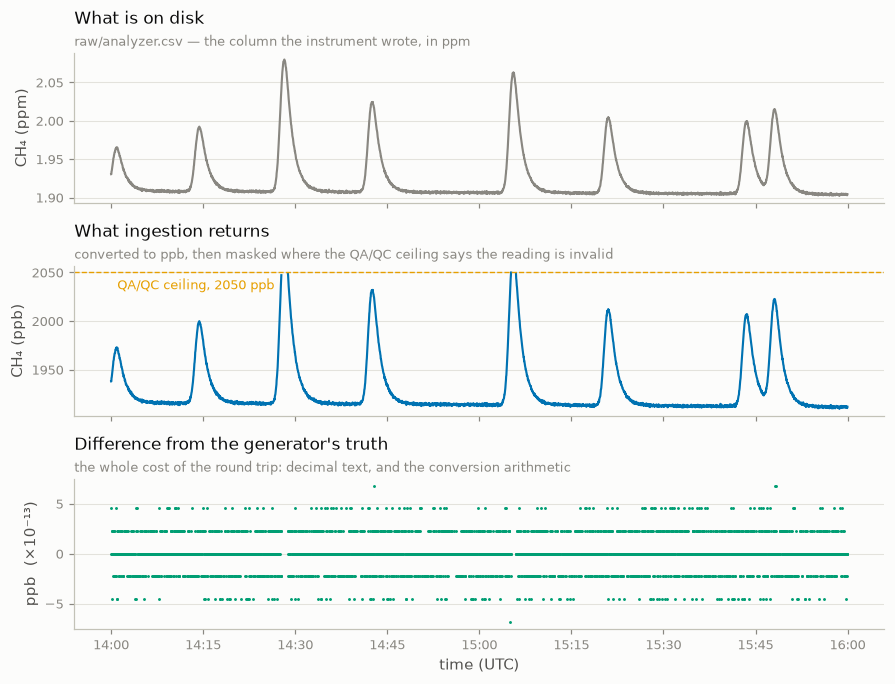

largest disagreement anywhere : 6.82e-13 ppb
one unit in the last place at 1900 ppb : 2.27e-13 ppb


In [3]:
written = pd.read_csv(manifest_path.parent / "raw" / "analyzer.csv", parse_dates=["time"])
t = streams["analyzer"]["time"].values
truth = dataset.streams["analyzer"]["ch4"].values

fig, axes = plt.subplots(3, 1, figsize=(9.5, 6.8), sharex=True, gridspec_kw={"hspace": 0.42})

axes[0].plot(written["time"], written["ch4"], color=MUTED)
finish(
    axes[0],
    "What is on disk",
    "raw/analyzer.csv — the column the instrument wrote, in ppm",
    "CH₄ (ppm)",
)

axes[1].plot(t, streams["analyzer"]["ch4"].values, color=C1)
axes[1].axhline(CEILING, color=C2, lw=0.9, ls="--")
axes[1].text(t[30], CEILING - 6, "QA/QC ceiling, 2050 ppb", color=C2, fontsize=8.5, va="top")
finish(
    axes[1],
    "What ingestion returns",
    "converted to ppb, then masked where the QA/QC ceiling says the reading is invalid",
    "CH₄ (ppb)",
)

residual = streams["analyzer"]["ch4"].values - truth
axes[2].plot(t, residual * 1e13, ".", color=C3, ms=1.8)
finish(
    axes[2],
    "Difference from the generator's truth",
    "the whole cost of the round trip: decimal text, and the conversion arithmetic",
    "ppb  (×10⁻¹³)",
    "time (UTC)",
)
hhmm(axes[2])
plt.show()

print(f"largest disagreement anywhere : {np.nanmax(np.abs(residual)):.2e} ppb")
print(f"one unit in the last place at 1900 ppb : {np.spacing(1900.0):.2e} ppb")

The bottom panel is worth a second look. It is not noise — it is **quantized**,
sitting on a handful of discrete levels. That is the signature of floating-point
representation rather than of any physical error: the values are landing one,
two or three units in the last place away from where they started, because they
made the trip through decimal text and back and were then multiplied and
shifted. The largest disagreement in the whole record is about 7 × 10⁻¹³ ppb,
which is roughly twelve orders of magnitude below the analyzer's own noise
floor.

§7 returns to this, because it is a knob rather than a fact: `float_precision:
exact` removes it entirely, at a cost.

---
## 2. The manifest is the whole interface

`export_raw` wrote a manifest beside the files, and it is an ordinary TSARA
manifest — the same schema a real campaign uses. Reading it is the fastest way
to see what ingestion is configured by.

In [4]:
show((manifest_path).read_text().rstrip())

name: ingest_demo
description: Manifest for synthetic dataset 'ingest_demo'.
base_path: raw
platform:
  kind: stationary
  latitude: 40.77
  longitude: -111.89
  altitude_m: null
instruments:
  analyzer:
    description: Synthetic instrument 'analyzer' at 2s.
    loader:
      path_templates:
      - analyzer.csv
      exclude: []
      support:
        label: mid
        width: 2s
        method: point
        start_column: null
        stop_column: null
      max_dropped_fraction: 0.5
      float_precision: fast
      format: csv
      time:
        columns:
        - time
        join: ' '
        format: iso8601
        timezone: UTC
      delimiter: ','
      header_row: 0
      column_names: null
      na_values: []
      comment: null
    variables:
      ch4:
        column: ch4
        field: null
        role: gas
        units: ppm
        convert:
          from_unit: ppm
          to_unit: ppb
          scale: 1000.0
          offset: 7.5
        circular: false
        un

Four blocks matter, and each answers a question no code should have to guess.

- **`base_path`** — where the archive is. Everything else is relative to it, so
  a campaign moves between a laptop and a cluster by editing one line. A
  relative `base_path` is read from the manifest's own directory, which is why
  this one says just `raw`: the exported archive and its manifest move together
  without editing anything.
- **`platform`** — stationary (one position, applied globally) or mobile (a GPS
  instrument named here, joined later). §10 covers the mobile case and why the
  join is deliberately *not* done at ingestion.
- **`loader`** — how to find and parse this instrument's files: the format name
  that selects a reader from the registry, one or more path templates, and where
  the timestamps live.
- **`variables`** — for each canonical name, which raw `column` it comes from,
  its `units`, an optional `convert` block, `qaqc` rules, and an `uncertainty`
  declaration. `role` says what kind of thing it is (`gas`, `met`, `gps_lat`…)
  and `circular` marks angular variables that must never be linearly averaged.

The canonical name is the key on the left; the file's own column name lives in
`column`. That indirection is what lets `CH4_ppbv`, `ch4_sync` and `[CH4]_ppb`
from three instruments all become `ch4` without any of the three readers knowing
that a rename happened.

---
## 3. Finding the files

An archive's layout is information. `SLC-SOS/2024_mobile/Univ_Montana/PTR_ToF_MS/…`
records which institution operated the instrument, and nothing inside the files
says so. Meanwhile the same campaign stores another instrument as
`NOAA_MobileLab_Drives/20240815/*.ict`, with the measurement date in a directory
name.

A path template describes one layout and mixes three kinds of token:

| token | meaning |
|---|---|
| `{field}` | matches one path segment and **harvests** it as metadata |
| `%Y %m %d` | strftime tokens; constrain to digits, deliberately *not* harvested |
| `*` `**` `?` `[abc]` | ordinary glob wildcards; `*` stays inside one segment |

Each template compiles to a **pair**: a glob to drive the filesystem walk (only
the filesystem can enumerate what exists) and a regex to harvest the `{field}`
values (a glob cannot report which text a wildcard consumed).

Below, a fabricated archive tree — empty files, just names — with two
institutions, a date hierarchy, a quarantine directory of the kind real archives
grow, and a macOS resource fork.

In [5]:
demo_archive = WORK / "demo_archive"
for relative in [
    "Univ_Utah/analyzer/2026/06/15/analyzer_20260615.csv",
    "Univ_Utah/analyzer/2026/06/16/analyzer_20260616.csv",
    "Univ_Utah/analyzer/2026/06/16/bad/analyzer_20260616.csv",  # quarantined in place
    "Univ_Utah/analyzer/2026/06/16/._analyzer_20260616.csv",  # macOS resource fork
    "Univ_Wyoming/analyzer/2026/06/15/analyzer_20260615.csv",
    "Univ_Wyoming/analyzer/2026/06/15/notes.txt",
]:
    target = demo_archive / relative
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_text("")

TEMPLATE = "{institution}/analyzer/%Y/%m/%d/*.csv"
TIME = {"column": "time", "format": "iso8601"}

pattern, harvester = compile_template(TEMPLATE)
print(f"template : {TEMPLATE}")
print(f"glob     : {pattern}")
print(f"regex    : {harvester.pattern}")
print()

for match in crawl(demo_archive, CSVLoader(path_template=TEMPLATE, time=TIME)):
    print(f"  {match.path.relative_to(demo_archive).as_posix():<55} {match.fields}")

template : {institution}/analyzer/%Y/%m/%d/*.csv
glob     : */analyzer/[0-9][0-9][0-9][0-9]/[0-9][0-9]/[0-9][0-9]/*.csv
regex    : (?P<institution>[^/]+)/analyzer/\d{4}/\d{2}/\d{2}/[^/]*\.csv

  Univ_Utah/analyzer/2026/06/15/analyzer_20260615.csv     {'institution': 'Univ_Utah'}
  Univ_Utah/analyzer/2026/06/16/analyzer_20260616.csv     {'institution': 'Univ_Utah'}
  Univ_Wyoming/analyzer/2026/06/15/analyzer_20260615.csv  {'institution': 'Univ_Wyoming'}


Three files, each carrying the institution its path implied — and `notes.txt`
was never a candidate, while the `._`-prefixed resource fork was skipped
unconditionally. That last one is not hypothetical: `pathlib.Path.glob` matches
dotfiles where `glob.glob` does not, so a Mac-touched archive hands every
`*.csv` template a binary shadow of each real file, which then fails to parse
and reports itself as an unreadable *data* file.

Now the trap. Archives whose depth varies invite a `**` template — and `**`
descends into the quarantine directory without a word.

In [6]:
sweeping = CSVLoader(path_template="{institution}/analyzer/**/*.csv", time=TIME)
print("** template:")
for match in crawl(demo_archive, sweeping):
    print(f"  {match.path.relative_to(demo_archive).as_posix()}")

guarded = CSVLoader(
    path_template="{institution}/analyzer/**/*.csv", exclude=["**/bad/**"], time=TIME
)
print()
print("...with exclude: ['**/bad/**']")
for match in crawl(demo_archive, guarded):
    print(f"  {match.path.relative_to(demo_archive).as_posix()}")

# A fixed metadata value is substituted into the search rather than harvested
# from it, which both narrows the scan and filters everything else out.
narrowed = CSVLoader(path_template=TEMPLATE, time=TIME)
print()
print("...restricted to one institution by the instrument's metadata block:")
for match in crawl(demo_archive, narrowed, metadata={"institution": "Univ_Wyoming"}):
    print(f"  {match.path.relative_to(demo_archive).as_posix():<55} {match.fields}")

** template:
  Univ_Utah/analyzer/2026/06/15/analyzer_20260615.csv
  Univ_Utah/analyzer/2026/06/16/analyzer_20260616.csv
  Univ_Utah/analyzer/2026/06/16/bad/analyzer_20260616.csv
  Univ_Wyoming/analyzer/2026/06/15/analyzer_20260615.csv

...with exclude: ['**/bad/**']
  Univ_Utah/analyzer/2026/06/15/analyzer_20260615.csv
  Univ_Utah/analyzer/2026/06/16/analyzer_20260616.csv
  Univ_Wyoming/analyzer/2026/06/15/analyzer_20260615.csv

...restricted to one institution by the instrument's metadata block:
  Univ_Wyoming/analyzer/2026/06/15/analyzer_20260615.csv  {'institution': 'Univ_Wyoming'}


Templates are include-only, and that is not sufficient: **archives quarantine
data in place**, keeping rejected files in `bad/` and `bad_timestamp/`
subdirectories sitting directly beneath the good ones. Saying "not that" is a
layout fact, so it belongs in the manifest beside the layout facts that find
files in the first place. `_BaseLoader.exclude` reports its count at INFO,
because a run that drops a third of an archive should say so at a level people
read — and excluding *everything* a template found is its own error, since
"the templates found nothing" and "the exclusions removed everything" have
opposite fixes.

On the archive this was built for, the 2026 processing stage keeps **187 of its
623 parquet files** in such directories — so a sweeping template silently
ingests a set that is thirty percent rejected data.

`docs/METHODS.md` §9.1.1 records what this cost to learn on the real archive,
including one silent failure worth knowing about: glob spells negation `[!abc]`
and regex spells it `[^abc]`, so a template using the glob spelling matched
files and then discarded every one of them in the harvesting regex, reporting
"no files found".

---
## 4. The reader seam

Ingestion has two halves with very different shapes. Reading a file is
format-specific and irreducibly fiddly. Everything after it — renaming,
converting, masking, resolving uncertainty, assembling — depends only on the
manifest. The seam between them is one contract:

```
(path, loader config) -> RawTable
```

where the returned frame is indexed by **tz-naive UTC nanosecond** timestamps
and keeps every column under **the name the raw file uses**. A reader that
renamed columns would have to be taught the manifest, which is exactly the
coupling the seam exists to prevent. The contract is enforced at runtime for
every reader — TSARA's own and anyone else's.

In [7]:
print("registered readers:", sorted(available_readers()))
print()

analyzer_csv = manifest_path.parent / "raw" / "analyzer.csv"
loader = load_manifest(manifest_path).instruments["analyzer"].loader
table = read_file(analyzer_csv, loader)

print("columns  :", list(table.frame.columns))  # the FILE's names, not canonical ones
print("index    :", table.frame.index.dtype, "| tz:", table.frame.index.tz)
print("rows     :", len(table.frame))
print()
print(table.frame.head(3).to_string())

registered readers: ['csv', 'icartt', 'parquet']

columns  : ['time', 'ch4', 'c2h6', 'c2h6_err']
index    : datetime64[ns] | tz: None
rows     : 3600

                                    time       ch4      c2h6  c2h6_err
time                                                                  
2026-06-15 14:00:00  2026-06-15T14:00:00  1.930434  3.389436      0.05
2026-06-15 14:00:02  2026-06-15T14:00:02  1.930502  3.504505      0.05
2026-06-15 14:00:04  2026-06-15T14:00:04  1.933966  3.450079      0.05


`ch4` here is still ~1.9, because this is the file's number in the file's units.
Nothing has been converted, masked, or renamed — the raw `time` column is even
still present under its own name, alongside the index built from it, because
"every column keeps the name the file gave it" is the contract and a reader does
not get to decide that one of them has now been used up.

Readers are selected by name from a registry (`@register_reader("csv")`) — the same decorator-registry
pattern `docs/METHODS.md` fixes for noise estimators and regression estimators,
so that a new format is a new module rather than a new branch in a dispatcher.

Three ship with TSARA. `csv` covers comma, tab and whitespace-run delimited
logger output, including headerless files whose column names come from the
manifest. `icartt` is the NASA/NOAA FFI-1001 format (§8) — TSARA parses it
itself rather than taking a dependency, because the obvious PyPI package is
GPL-3.0 and TSARA is MIT. `parquet` reads processed campaign stages.

---
## 5. Convert, then mask, then resolve — in that order

Three things happen to every variable, and the order is fixed because each step
depends on the one before it (`docs/METHODS.md` §9.4):

| step | why it is here |
|---|---|
| convert units | so everything downstream reads canonical numbers |
| apply QA/QC | bounds are written in the units their author thinks in |
| resolve uncertainty | a declared `absolute` sigma is in canonical units |

The `ch4` column in this campaign is written in ppm and declared with a
conversion back to ppb — `value * 1000 + 7.5`. That the offset is non-zero is
the point:

In [8]:
raw_ppm = written["ch4"].to_numpy()

correct = raw_ppm * PPM.scale + PPM.offset  # scale, then shift
swapped = (raw_ppm + PPM.offset) * PPM.scale  # shift, then scale
print(
    f"offset = {PPM.offset}: the two orderings differ by up to "
    f"{np.max(np.abs(correct - swapped)):,.0f} ppb"
)

no_offset = raw_ppm * PPM.scale
print(
    f"offset = 0.0: the two orderings differ by "
    f"{np.max(np.abs(no_offset - (raw_ppm + 0.0) * PPM.scale)):.0f} ppb — "
    "they are the same function"
)
print()
print(
    f"ingestion landed within {np.nanmax(np.abs(residual)):.1e} ppb of truth, "
    "so it applied the declared ordering"
)

offset = 7.5: the two orderings differ by up to 7,493 ppb
offset = 0.0: the two orderings differ by 0 ppb — they are the same function

ingestion landed within 6.8e-13 ppb of truth, so it applied the declared ordering


That is a real lesson from this phase and it was found by mutation testing
rather than by reading: an ordering bug in unit conversion is **invisible** to
any test whose conversion has a zero offset, because the two orderings are then
literally the same function. The round-trip harness now always converts with
both a scale and an offset.

### QA/QC masks; it never deletes

A `range` rule is a physical statement in canonical units — here, an analyzer
that cannot report above 2050 ppb. Rules **mask** rather than remove rows,
because rows are the instrument's clock: a rolling window that closes over a
deleted sample computes a different answer than one that sees a gap, and "no
valid measurement" must stay distinguishable from "no measurement attempted".

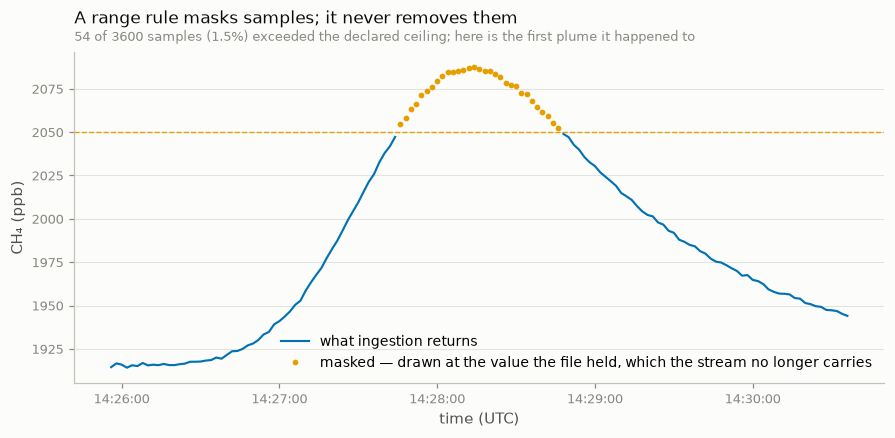

sample count unchanged by masking : True

  analyzer  ch4       rules -> range:54   masked_fraction = 0.0150
  met       wind_dir  rules -> range:0   masked_fraction = 0.0000


In [9]:
values = streams["analyzer"]["ch4"].values
masked = np.isnan(values)

# Zoom on the first contiguous run of masked samples; the whole record is in
# figure 1, and what needs looking at here is one plume top.
starts = np.flatnonzero(np.diff(masked.astype(int)) == 1)
first = int(starts[0]) + 1
last = first + int(np.argmin(masked[first:]))
window = slice(max(first - 55, 0), min(last + 55, len(masked)))

fig, ax = plt.subplots(figsize=(9.5, 3.9))
ax.plot(t[window], values[window], color=C1, label="what ingestion returns")
ax.plot(
    t[window][masked[window]],
    truth[window][masked[window]],
    ".",
    color=C2,
    ms=5.5,
    label="masked — drawn at the value the file held, which the stream no longer carries",
)
ax.axhline(CEILING, color=C2, lw=0.9, ls="--")
finish(
    ax,
    "A range rule masks samples; it never removes them",
    f"{int(masked.sum())} of {masked.size} samples ({masked.mean():.1%}) exceeded the declared "
    "ceiling; here is the first plume it happened to",
    "CH₄ (ppb)",
    "time (UTC)",
    legend=True,
    loc="lower right",
)
hhmm(ax, "%H:%M:%S")
plt.show()

same_length = streams["analyzer"].sizes["time"] == dataset.streams["analyzer"].sizes["time"]
print(f"sample count unchanged by masking : {same_length}")
print()
for instrument in ("analyzer", "aeris", "met"):
    for name, variable in streams[instrument].data_vars.items():
        if "qaqc_masked" in variable.attrs:
            print(
                f"  {instrument:9} {str(name):9} rules -> {variable.attrs['qaqc_masked']}"
                f"   masked_fraction = {variable.attrs['masked_fraction']:.4f}"
            )

Counts are reported **per rule**, not as one total, because the failure modes
are different and one combined number cannot tell them apart: a range rule that
masks everything means the bounds are in the wrong units, while a flag rule that
masks everything means the polarity is inverted. Here `wind_dir`'s
`0–360` bound masked nothing, and it still says so — a rule that never fires is
worth seeing in the output, since the alternative is discovering later that it
was silently inert.

**And now the uncomfortable part of this figure.** The samples that got masked
are the *top of a plume* — the most information-rich points in the record. That
is correct behaviour if 2050 ppb really is where the analyzer saturates, and a
catastrophe if the number was picked by looking at a histogram. A QA/QC bound in
TSARA is a statement about the **instrument**, never about the air.

This is also why TSARA has **no spike rule**. It had one — a rolling median/MAD
Hampel filter — and it was removed during this phase, because its operating
definition (a short excursion, large relative to a local robust scale) *is* the
definition of a plume in mobile data. Measured on real records, a large fraction
of clear enhancement events are only one or two samples wide, so no window or
threshold separates a glitch from a real event; the filter masked plume samples
several times more often than quiet air. Glitch rejection belongs where the
information actually exists — an instrument status column, a physical bound, or
a later stage that knows what a plume is. `docs/METHODS.md` §9.5 keeps the full
argument, because "we considered an outlier filter and rejected it" is a
methodological statement, not an omission.

---
## 6. Uncertainty: what a manifest can state, and what ingestion refuses to invent

Every variable may declare a two-component error budget, and the two components
are kept apart for the whole life of the pipeline because they behave
differently under averaging (`docs/METHODS.md` §2.1): a **random** component is
uncorrelated point to point and shrinks as ~1/√N, while a **systematic** one is
correlated and does not shrink at all, ever.

There are two ways a manifest can state a component — `declared` (an absolute or
relative term written in the YAML) and `reported` (a per-point sigma column the
instrument publishes, EM27-style). Ingestion computes exactly those two, and
**labels** everything else rather than guessing. The three species in this
campaign were chosen to produce three different answers.

In [10]:
print(f"{'instrument':10} {'variable':9} {'random':>10} {'systematic':>11}   sigma variables")
print("-" * 78)
for instrument in ("analyzer", "aeris", "met"):
    stream = streams[instrument]
    for name, variable in stream.data_vars.items():
        if str(name).startswith("sigma_"):
            continue
        companions = [str(v) for v in stream.data_vars if str(v).endswith(f"_{name}")]
        print(
            f"{instrument:10} {str(name):9} "
            f"{variable.attrs['uncertainty_provenance_random']:>10} "
            f"{variable.attrs['uncertainty_provenance_systematic']:>11}   "
            f"{companions if companions else '—'}"
        )

instrument variable      random  systematic   sigma variables
------------------------------------------------------------------------------
analyzer   ch4         declared    declared   ['sigma_rand_ch4', 'sigma_sys_ch4']
analyzer   c2h6        reported        zero   ['sigma_rand_c2h6']
aeris      aeris_ch4   declared        zero   ['sigma_rand_aeris_ch4']
met        wind_dir   empirical     unknown   —


Read the labels, because the distinctions are the point.

- **`declared`** — the manifest said so, and ingestion computed it.
- **`reported`** — the manifest named a column in the file, and ingestion read
  it. `c2h6_err` never appears as a variable; it becomes `sigma_rand_c2h6`.
- **`zero`** — `c2h6` declared a budget that *deliberately omits* a systematic
  term. That is a claim.
- **`unknown`** — `wind_dir` declared no budget at all. That is the absence of a
  claim, and collapsing it into `zero` would silently turn an undeclared
  calibration into an assertion of perfect calibration.
- **`empirical`** — nothing usable was declared, so a later phase will estimate
  the noise from the data itself with the robust first-difference estimator
  (`diff_mad`, `docs/METHODS.md` §2.5). Ingestion labels this and stops: the
  estimator's configuration lives in `DetectionConfig`, which is a Phase-5/6
  object that ingestion has no business reading.

The `zero` / `unknown` split is the kind of distinction that looks pedantic
until a combined confidence interval depends on it.

### The asymmetry a unit conversion exposes

`ch4` is converted ppm → ppb, and its random sigma is *declared* as
`absolute: 0.7`. A declared absolute sigma is already in canonical units, so it
must survive the conversion **untouched**:

In [11]:
sigma_random = streams["analyzer"]["sigma_rand_ch4"].values
sigma_systematic = streams["analyzer"]["sigma_sys_ch4"].values

print(
    f"declared random sigma, after a ×1000 unit conversion : "
    f"{np.unique(sigma_random[np.isfinite(sigma_random)])} ppb"
)
print(
    f"systematic, declared as 0.5% of a ~1900 ppb reading  : {np.nanmean(sigma_systematic):.2f} ppb"
)
print()
print(
    f"samples with no sigma, because QA/QC masked the value : "
    f"{int(np.isnan(sigma_random).sum())}  (the same {int(masked.sum())} samples)"
)

declared random sigma, after a ×1000 unit conversion : [0.7] ppb
systematic, declared as 0.5% of a ~1900 ppb reading  : 9.64 ppb

samples with no sigma, because QA/QC masked the value : 54  (the same 54 samples)


Two smaller things are visible in that output. A masked sample carries no
uncertainty either — the sigma companions are NaN in exactly the places the
QA/QC rule masked, because a sigma attached to a value that does not exist is
not a number anybody should be able to use by accident. And the systematic
component is *not* constant: it was declared as a fraction of the reading, so it
tracks the signal, which is precisely why it cannot be averaged away.

Had `c2h6` also been written in ppm, its *reported* `c2h6_err` column would have
been multiplied by 1000 — because a column in the file is in the file's units —
but never shifted by the offset, since an offset moves a measurement and not its
spread. Declared absolute: untouched. Reported column: scaled, never offset.
That asymmetry is where a real bug lived during this phase, and it is now
checked against the generator's own sigmas rather than against a hand-written
expectation.

One more thing ingestion does here that is easy to miss: a reported sigma column
is checked for negative values — almost always an undeclared `-9999` sentinel —
**before** the unit conversion is applied to it, because the conversion takes an
absolute value (a negative scale is a legitimate sign-convention flip). Ordered
the other way, the guard finds nothing and a `-9999` under a ppm→ppb conversion
enters the budget as a silent 9,999,000 ppb "1σ", which drives that point's
weight to zero.

---
## 7. What reading a number costs

Converting decimal text into a binary double is not free of choices. pandas'
default CSV parser is fast and *usually* exact; it is not guaranteed to return
the nearest double to the digits written. Both text readers therefore expose
`float_precision: fast | exact`, defaulting to `fast`.

Here is the whole difference, measured on this record — the same campaign
exported without a unit conversion, so that what is being measured is the parse
alone.

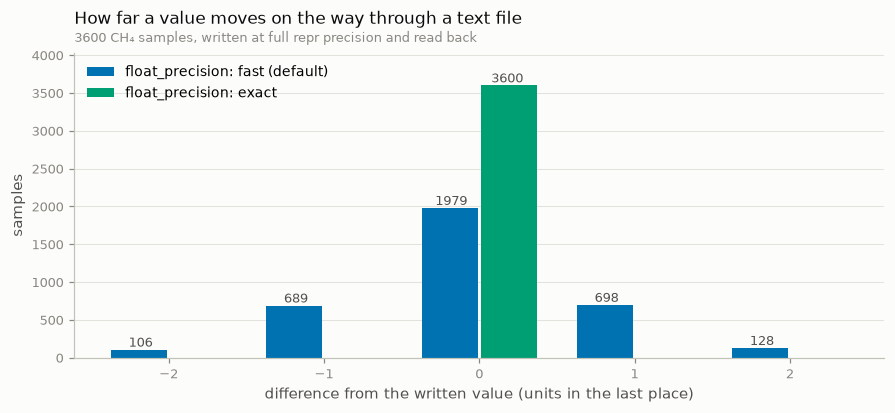

fast  : 55.0% of values recovered bitwise
exact : 100.0% of values recovered bitwise


In [12]:
plain_manifest = export_raw(dataset, WORK / "plain")
fast = ingest_campaign(load_manifest(plain_manifest))["analyzer"]["ch4"].values

payload = yaml.safe_load(plain_manifest.read_text())
for instrument in payload["instruments"].values():
    instrument["loader"]["float_precision"] = "exact"
plain_manifest.write_text(yaml.safe_dump(payload, sort_keys=False))
exact = ingest_campaign(load_manifest(plain_manifest))["analyzer"]["ch4"].values

# How many units in the last place each value moved.
ulp_fast = np.round((fast - truth) / np.spacing(truth)).astype(int)
ulp_exact = np.round((exact - truth) / np.spacing(truth)).astype(int)
offsets = np.arange(-2, 3)
counts_fast = [int((ulp_fast == o).sum()) for o in offsets]
counts_exact = [int((ulp_exact == o).sum()) for o in offsets]

fig, ax = plt.subplots(figsize=(9.5, 3.6))
width = 0.36
ax.bar(
    offsets - width / 2 - 0.01,
    counts_fast,
    width=width,
    color=C1,
    label="float_precision: fast (default)",
)
ax.bar(
    offsets + width / 2 + 0.01, counts_exact, width=width, color=C3, label="float_precision: exact"
)
for offset, count in zip(offsets, counts_fast):
    if count:
        ax.text(offset - width / 2, count + 40, f"{count}", ha="center", fontsize=8.5, color=INK2)
ax.text(
    width / 2, counts_exact[2] + 40, f"{counts_exact[2]}", ha="center", fontsize=8.5, color=INK2
)
ax.set_xticks(offsets)
ax.set_ylim(0, max(counts_exact) * 1.12)
finish(
    ax,
    "How far a value moves on the way through a text file",
    f"{len(truth)} CH₄ samples, written at full repr precision and read back",
    "samples",
    "difference from the written value (units in the last place)",
    legend=True,
    loc="upper left",
)
plt.show()

print(f"fast  : {(ulp_fast == 0).mean():.1%} of values recovered bitwise")
print(f"exact : {(ulp_exact == 0).mean():.1%} of values recovered bitwise")

Synthetic data is the *worst* case for this, and deliberately so: `export_raw`
writes at `repr` precision, so every value carries all 17 significant digits it
possibly can. Real instrument files do not — the overwhelming majority of values
in a real archive carry nine digits or fewer, and those parse identically either
way, which is why the disagreement rate measured on the real 2024 archive is a
fraction of a percent rather than the ~45% seen here.

So the default is a measurement, not a guess: a fraction of a percent of values
moving by roughly thirteen orders of magnitude less than any instrument's
precision, against a double-digit percentage increase in the slowest step of the
workflow. `exact` exists because "my ingestion is bitwise reproducible" is a
legitimate thing to need — for a regression test, a published dataset, or an
argument with a collaborator's pipeline — and because it should be one line of
YAML rather than a patch. The measured numbers are in `docs/METHODS.md` §9.2.2.

---
## 8. ICARTT, and two kinds of sentinel

Everything so far went through CSV, because a round trip only constrains the
*reader* when the writer is trivially correct, and TSARA does not ship an ICARTT
writer for exactly that reason. But ICARTT is the format that most of this phase
was really written for, and it has a property worth seeing.

An FFI-1001 file is self-describing: a header states how many lines it has, who
wrote it, what the columns are, what scale factor each carries, and what value
means "missing". Below is a hand-written miniature — not a measurement, and not
copied from any archive, but reproducing faithfully a structure that is
everywhere in the real one.

In [13]:
ICARTT_HEADER = """\
26, 1001
Doe, Jane
Example Organization
Proton-transfer-reaction mass spectrometer
DEMO-CAMPAIGN
1, 1
2026, 06, 15, 2026, 06, 20
1
Time_Start, seconds_past_midnight, Seconds from midnight UTC
2
1.0, 1.0
-9999, -9999
CH4_ppbv, ppbv, Methane mixing ratio
benzene_ppbv, ppbv, Benzene mixing ratio
4
SPECIAL COMMENTS:
ULOD_FLAG: -88888
LLOD_FLAG: -88888
LLOD_VALUE: 0.015
6
PI_CONTACT_INFO: jane.doe@example.org
PLATFORM: Mobile laboratory
DATA_INFO: Hand-written miniature; not a measurement
REVISION: R0
R0: initial release
Time_Start, CH4_ppbv, benzene_ppbv
"""

ICARTT_ROWS = """\
50400, 1903.1, -88888
50401, 1902.6, -88888
50402, 1904.0, -88888
50403, 1903.4, -88888
50404, 1905.9, -88888
50405, 1912.7, -88888
50406, 1928.4, -88888
50407, 1963.2, 0.187
50408, 2008.5, 0.402
50409, 2041.9, 0.573
50410, 2054.3, 0.641
50411, -9999, 0.628
50412, 2036.8, 0.559
50413, 2014.2, 0.478
50414, 1990.6, 0.395
50415, 1968.1, 0.311
50416, 1949.7, 0.238
50417, 1935.2, -88888
50418, 1924.8, -88888
50419, 1917.3, -88888
50420, 1911.9, -88888
50421, 1908.2, -88888
50422, 1905.7, -88888
50423, 1904.1, -88888
"""

ict_path = WORK / "DEMO-PTRMS_MobileLab_20260615_R0.ict"
ict_path.write_text(ICARTT_HEADER + ICARTT_ROWS)

header = parse_icartt_header(ict_path.read_text().splitlines(), ict_path)
print("PI              :", header.pi_name)
print("mission         :", header.mission)
print("data date       :", header.data_date)
print("variables       :", [v.name for v in header.variables])
print("VMISS per column:", [v.missing for v in header.variables])
print("scale factors   :", [v.scale for v in header.variables])
print("LOD flags       :", {k: v for k, v in header.metadata.items() if "LOD" in k})

PI              : Doe, Jane
mission         : DEMO-CAMPAIGN
data date       : 2026-06-15
variables       : ['CH4_ppbv', 'benzene_ppbv']
VMISS per column: [-9999.0, -9999.0]
scale factors   : [1.0, 1.0]
LOD flags       : {'ULOD_FLAG': '-88888', 'LLOD_FLAG': '-88888', 'LLOD_VALUE': '0.015'}


There are **two unrelated families of sentinel** in that header, and conflating
them is the difference between a stream that can be analyzed and one that
cannot.

- **`VMISS`** (`-9999` here, declared per column) marks data that is *missing*.
  The instrument produced nothing.
- **`ULOD_FLAG` / `LLOD_FLAG`** (`-88888`) mark samples that fell **outside the
  instrument's detection range**. Scientifically these are not missing at all: a
  below-detection benzene is an upper bound, which is real information.

That distinction is genuine, and for a long time it was the argument for leaving
the LOD values in place and carrying the flags forward. Here is what settled it
the other way.

In [14]:
naive = pd.read_csv(
    ict_path, skiprows=26, header=None, names=["Time_Start", "CH4_ppbv", "benzene_ppbv"]
)
table = read_icartt(ict_path, ICARTTLoader(path_template="*.ict"))

print("what the characters in the file say:")
print(f"   benzene median = {np.median(naive['benzene_ppbv']):.0f} ppbv")
print(f"   CH₄     median = {np.median(naive['CH4_ppbv']):.1f} ppbv")
print()
print("what the reader returns:")
print(f"   benzene median = {np.nanmedian(table.frame['benzene_ppbv']):.3f} ppbv")
print(f"   CH₄     median = {np.nanmedian(table.frame['CH4_ppbv']):.1f} ppbv")
print()
print("counts kept, so a later phase can still model the censoring:")
print(f"   below/above detection : {table.attrs['icartt_lod_masked']}")
print(f"   declared LLOD value   : {table.attrs['icartt_llod_value']} ppbv")

what the characters in the file say:
   benzene median = -88888 ppbv
   CH₄     median = 1921.0 ppbv

what the reader returns:
   benzene median = 0.440 ppbv
   CH₄     median = 1924.8 ppbv

counts kept, so a later phase can still model the censoring:
   below/above detection : {'benzene_ppbv': 14}
   declared LLOD value   : 0.015 ppbv


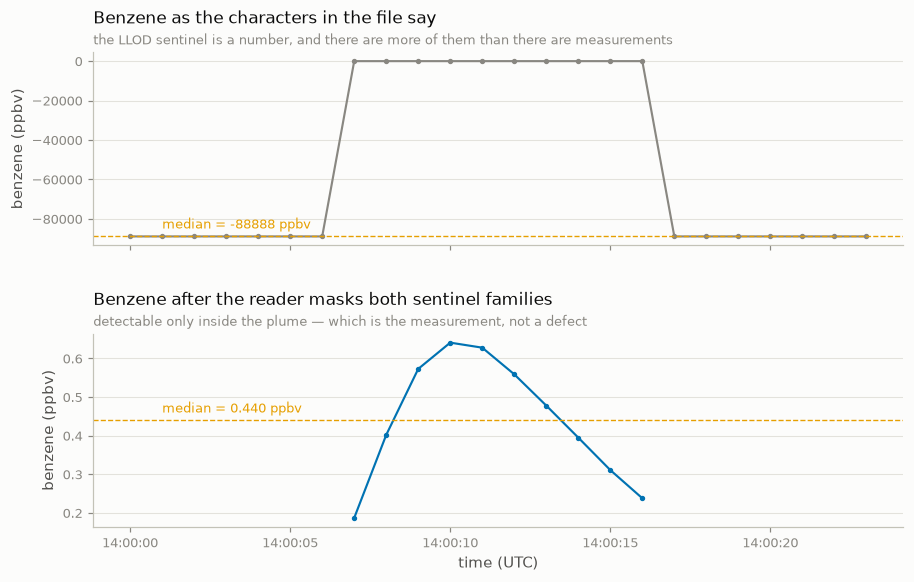

In [15]:
times = table.frame.index

fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.6), sharex=True, gridspec_kw={"hspace": 0.46})

naive_median = float(np.median(naive["benzene_ppbv"]))
axes[0].plot(times, naive["benzene_ppbv"].to_numpy(), color=MUTED, marker=".", ms=5)
axes[0].axhline(naive_median, color=C2, lw=0.9, ls="--")
axes[0].text(
    times[1], naive_median + 4000, f"median = {naive_median:.0f} ppbv", color=C2, fontsize=8.5
)
finish(
    axes[0],
    "Benzene as the characters in the file say",
    "the LLOD sentinel is a number, and there are more of them than there are measurements",
    "benzene (ppbv)",
)

masked_median = float(np.nanmedian(table.frame["benzene_ppbv"]))
axes[1].plot(times, table.frame["benzene_ppbv"].to_numpy(), color=C1, marker=".", ms=5)
axes[1].axhline(masked_median, color=C2, lw=0.9, ls="--")
axes[1].text(
    times[1], masked_median + 0.02, f"median = {masked_median:.3f} ppbv", color=C2, fontsize=8.5
)
finish(
    axes[1],
    "Benzene after the reader masks both sentinel families",
    "detectable only inside the plume — which is the measurement, not a defect",
    "benzene (ppbv)",
    "time (UTC)",
)
hhmm(axes[1], "%H:%M:%S")
plt.show()

The record is 58% sentinel, so **the median of the file is the sentinel**. A
rolling low-quantile baseline — which is exactly what Phase 5 computes — would
have reported a background of −88888 ppbv, and every enhancement ratio built on
it would have been meaningless. Leaving those values in place was not a
conservative choice; it was a silent one.

This is not a contrived miniature. On the real 2024 archive, 913 of 1122 files
declare a numeric LOD sentinel, in three different magnitudes, and the affected
share of values inside the VOC files runs to a third or more; the measured table
is in `docs/METHODS.md` §9.2.1. The policy chosen is to **mask and keep**: the
values become NaN, and the flag values plus a per-variable count travel on into
the stream, attached to the species they censor, so a later phase can substitute
LOD/2 or fit a censored model without re-reading a single file.

**A detail worth telling, because it is what walkthroughs are for.** This bug
was unreachable in principle until a second one was fixed. Header metadata used
to be scraped only from the two comment blocks, located by counting `12 + NV`
lines — and the files with the highest below-detection fractions in the archive
carry one extra, blank-named variable-definition line, which offsets that walk.
Both blocks were then read from the wrong place, so `metadata` came back
**empty on exactly the files that declared the LOD flags**. Masking was a no-op
until the metadata reached it. Metadata is now scraped from the whole header,
since a `KEY: value` line means the same thing wherever it sits.

Notice also the row at 14:00:11, where CH₄ is `-9999` and benzene is a perfectly
good 0.628. Two sentinel families, in one row, meaning different things, masked
for different reasons.

### When files disagree about themselves

One file is the easy case. An instrument is usually *many* files, and they do
not all say the same thing about themselves: a campaign gets reprocessed in
batches, a revision is issued for one day and not the rest, a second drive goes
out on a day that already has a file. Whatever ingestion writes into the
stream's attrs is a claim that somebody will read months later without the
files beside them, so the question is what to do when a dozen headers disagree.

Below, twelve miniatures of the same shape as the one above — same PI and
mission in every one, ten different data dates, two revision batches, and their
own below-detection counts. Three are deliberately awkward: one is a superseded
revision of a day another file also covers, one repeats a timestamp inside
itself, and one is a second drive overlapping a day already ingested.

In [16]:
# The library default is silence: `tsara/__init__.py` attaches a NullHandler to
# the package logger, so importing TSARA never writes to a host application's
# console uninvited. From here on the log messages are the point — they are how
# ingestion reports what it dropped and why — so attach TSARA's own handler. It
# touches the `tsara` logger only, never the root.
scrub_paths_from_logs(setup_logging(logging.INFO))

ICARTT_SET = WORK / "icartt_set"
ICARTT_SET.mkdir()


def write_miniature(day, revision, rows, comment=None):
    """Write one FFI-1001 miniature differing from its siblings on purpose.

    Only the fields a real archive actually varies between files are
    parameterized — the data date, the revision, and the rows. The header stays
    26 lines long, so `NLHEAD` remains honest.
    """
    date = pd.Timestamp("2026-06-15") + pd.Timedelta(days=day)
    revised = "2026, 06, 20" if revision == "R0" else "2026, 07, 01"
    note = "initial release" if revision == "R0" else "reprocessed batch"
    header = ICARTT_HEADER.replace("2026, 06, 15, 2026, 06, 20", f"{date:%Y, %m, %d}, {revised}")
    header = header.replace("REVISION: R0", f"REVISION: {revision}")
    header = header.replace("R0: initial release", f"{revision}: {note}")
    suffix = f"_{comment}" if comment else ""
    name = f"DEMO-PTRMS_MobileLab_{date:%Y%m%d}_{revision}{suffix}.ict"
    (ICARTT_SET / name).write_text(header + rows)


def miniature_rows(seed, n=20, start=50400):
    """Build a short plume whose benzene falls below the declared LLOD either side."""
    rng = np.random.default_rng(seed)
    lines = []
    for i in range(n):
        bump = np.exp(-((i - n / 2) ** 2) / 8.0)
        ch4 = 1900 + 44 * bump + rng.normal(0, 1.2)
        benzene = 0.62 * bump
        # Below the LLOD_VALUE the header declares, the instrument reports the
        # flag rather than a number — which is the whole subject of this section.
        reported = f"{benzene:.3f}" if benzene > 0.015 else "-88888"
        lines.append(f"{start + i}, {ch4:.1f}, {reported}")
    return "\n".join(lines) + "\n"


for day in range(10):
    write_miniature(day, "R0" if day < 5 else "R1", miniature_rows(day))
# A revised release of the first day: same product, newer revision.
write_miniature(0, "R1", miniature_rows(0))
# A logger that wrote two records under one timestamp.
doubled = miniature_rows(6).splitlines()
write_miniature(6, "R1", "\n".join(doubled[:8] + [doubled[7]] + doubled[8:]) + "\n")
# A second drive on day 3, overlapping the first by ten seconds.
write_miniature(3, "R0", miniature_rows(33, start=50410), comment="drive2")

PTRMS_SET = {
    "name": "ptrms_set",
    "base_path": str(ICARTT_SET),
    "platform": {"kind": "stationary", "latitude": 40.77, "longitude": -111.89},
    "instruments": {
        "ptrms": {
            "loader": {"format": "icartt", "path_template": "*.ict", "revision_policy": "latest"},
            "variables": {
                "ch4": {"column": "CH4_ppbv", "units": "ppbv", "role": "gas"},
                "benzene": {"column": "benzene_ppbv", "units": "ppbv", "role": "gas"},
            },
        }
    },
}

ptrms = ingest_campaign(Manifest.model_validate(PTRMS_SET))["ptrms"]

print()
print(f"files written  : {len(list(ICARTT_SET.glob('*.ict')))}")
print(f"files ingested : {ptrms.attrs['n_files']}")
print(f"samples        : {ptrms.sizes['time']}")
print()
print("what these files said about themselves, reconciled into one stream:")
for key, value in sorted(ptrms.attrs.items()):
    if key.startswith("icartt_"):
        print(f"   {key:24} {str(value)[:90]}")

print()
print("and the below-detection tally, summed over files onto the species it censors:")
for name, variable in ptrms.data_vars.items():
    print(f"   {str(name):24} n_lod_masked = {variable.attrs.get('n_lod_masked', 0)}")

2026-09-23 12:15:19 | INFO     | tsara.ingest.campaign | Ingesting instrument 'ptrms'.


2026-09-23 12:15:19 | INFO     | tsara.ingest.icartt | revision_policy='latest' superseded 1 ICARTT file(s).


2026-09-23 12:15:19 | INFO     | tsara.ingest.icartt | <work>/icartt_set/DEMO-PTRMS_MobileLab_20260615_R1.ict: masked out-of-detection-range samples: benzene_ppbv:9.


2026-09-23 12:15:19 | INFO     | tsara.ingest.icartt | <work>/icartt_set/DEMO-PTRMS_MobileLab_20260616_R0.ict: masked out-of-detection-range samples: benzene_ppbv:9.


2026-09-23 12:15:19 | INFO     | tsara.ingest.icartt | <work>/icartt_set/DEMO-PTRMS_MobileLab_20260617_R0.ict: masked out-of-detection-range samples: benzene_ppbv:9.


...

2026-09-23 12:15:19 | INFO     | tsara.ingest.icartt | <work>/icartt_set/DEMO-PTRMS_MobileLab_20260623_R1.ict: masked out-of-detection-range samples: benzene_ppbv:9.


2026-09-23 12:15:19 | INFO     | tsara.ingest.icartt | <work>/icartt_set/DEMO-PTRMS_MobileLab_20260624_R1.ict: masked out-of-detection-range samples: benzene_ppbv:9.


2026-09-23 12:15:19 | WARNING  | tsara.ingest.campaign | Instrument 'ptrms': dropped 11 row(s) sharing a timestamp with an earlier row (kept the first of each): 1 duplicated within a single file (the instrument logged two records under one timestamp), 10 from overlap between files (check the manifest's path templates).


2026-09-23 12:15:19 | INFO     | tsara.ingest.campaign | Instrument 'ptrms': 210 samples from 11 file(s).



files written  : 12
files ingested : 11
samples        : 210

what these files said about themselves, reconciled into one stream:
   icartt_data_date         2026-06-15 ... 2026-06-24 (10 distinct values)
   icartt_instrument_description Proton-transfer-reaction mass spectrometer
   icartt_interval          1.0
   icartt_llod_flag         -88888
   icartt_llod_value        0.015
   icartt_mission           DEMO-CAMPAIGN
   icartt_organization      Example Organization
   icartt_pi                Doe, Jane
   icartt_platform          Mobile laboratory
   icartt_revision          R0; R1
   icartt_revision_date     2026-06-20; 2026-07-01
   icartt_ulod_flag         -88888

and the below-detection tally, summed over files onto the species it censors:
   ch4                      n_lod_masked = 0
   benzene                  n_lod_masked = 99


Four different rules are visible in that output, and each one is a decision
about what a saved product is allowed to claim.

- **Agree, so carry it.** `icartt_pi`, `icartt_mission`, the LOD flag values —
  every file said the same thing, so the stream says it too.
- **Disagree, so join — never pick.** `icartt_revision` comes back as both
  batches, and `icartt_revision_date` as both dates. Choosing one would have put
  a false statement in a product that advertises itself as self-describing. This
  is not hypothetical: the real PTR-MS set was released in two batches, and the
  attr that reports both is the only place a reader would ever find that out.
- **Disagree in every file, so summarize.** `icartt_data_date` differs by
  design — it is a per-file property, not a campaign one. Past eight distinct
  values it collapses to first, last and a count, because a thousand-file
  instrument would otherwise write a thousand-item attr that is unreadable in
  `ncdump -h` and useless as provenance.
- **Counts, so sum them.** The per-file below-detection tallies are not in
  conflict; they add. They also travel *down* rather than sideways, arriving as
  `n_lod_masked` on the variable they censor rather than as a stream-level attr,
  because a count of censored benzene samples is a fact about benzene. A tally
  over files is exactly the tally over the concatenated record.

The log lines above the table are the other half of the story, and both name
their cause rather than guessing at it.

`revision_policy='latest'` superseded one file: day one exists as `R0` and `R1`,
and ingesting both would have counted that air twice. What it did **not** drop
is the second drive — `..._20260618_R0_drive2.ict` — because de-duplication keys
on everything through the trailing comment, and two files differing after the
revision token are different data, not revisions of each other. The
specification this phase started from would have discarded roughly 12% of the
real archive on that distinction alone.

Then the duplicate-timestamp warning, which reports **two counts, separately**:
rows duplicated *within* a single file, and rows arriving from *overlap between*
files. They call for opposite fixes — a within-file repeat is a logger writing
two records under one second, so the answer is a resolution or averaging
decision; an overlap is the archive genuinely holding one period twice, so the
answer is in the manifest's path templates. That message used to guess
"Overlapping files?". Measured on the real 43-file set, all 7,242 dropped rows
were within-file and **none** came from overlap, so the guess pointed at the
crawler and the revision policy, both innocent. Counting the two causes before
the files are concatenated costs one line and makes the split exact.

---
## 9. What a stream is

The output of ingestion is one `xarray.Dataset` per instrument, and it is
deliberately shaped **exactly** like a stream the synthetic generator
manufactures. That is not tidiness: it is the requirement that makes the
generator useful at all. Every later phase — baselines, detection, regression —
must consume real and synthetic data through one code path, or synthetic truth
stops being able to arbitrate anything.

In [17]:
stream = streams["analyzer"]

print("dataset attrs — the stream explains itself")
width = max(map(len, stream.attrs))
for key, value in stream.attrs.items():
    print(f"   {key:{width}} {value}")

print()
print("variable attrs — ch4")
width = max(map(len, stream["ch4"].attrs))
for key, value in stream["ch4"].attrs.items():
    print(f"   {key:{width}} {value}")

print()
print(
    "coordinates:",
    {name: str(coord.values) for name, coord in stream.coords.items() if name != "time"},
)
print(
    "time:", stream["time"].values[0], "…", stream["time"].values[-1], f"({stream['time'].dtype})"
)

dataset attrs — the stream explains itself
   tsara_version                   0.1.0
   tsara_stage                     ingest
   instrument                      analyzer
   platform_kind                   stationary
   n_files                         1
   loader_format                   csv
   tsara_support_label             mid
   tsara_cell_coverage             1.0
   tsara_support_label_provenance  declared
   tsara_support_width_provenance  declared
   tsara_support_method_provenance declared
   tsara_nominal_cell_width_s      2.0
   campaign                        ingest_demo
   description                     Synthetic instrument 'analyzer' at 2s.

variable attrs — ch4
   units                             ppb
   role                              gas
   field                             ch4
   circular                          0
   raw_column                        ch4
   uncertainty_provenance            declared
   uncertainty_provenance_random     declared
   uncertainty_proven

A stationary platform's position is a scalar coordinate on every stream, applied
globally from the manifest — exact and free. `tsara_stage: ingest` is not
decoration either: a file found on disk in six months has to be able to say what
produced it, which package version, and from how many files.

Now the claim about substitutability, checked rather than asserted:

In [18]:
generated_vars = sorted(dataset.observable("analyzer").data_vars)
ingested_vars = sorted(streams["analyzer"].data_vars)

print("generator, answer key removed :", generated_vars)
print("ingestion, from files         :", ingested_vars)
print()
print("(the generator publishes its raw sigma column, c2h6_err, exactly as an")
print(" instrument would; ingestion consumes it into sigma_rand_c2h6)")

generator, answer key removed : ['c2h6', 'c2h6_err', 'ch4']
ingestion, from files         : ['c2h6', 'ch4', 'sigma_rand_c2h6', 'sigma_rand_ch4', 'sigma_sys_ch4']

(the generator publishes its raw sigma column, c2h6_err, exactly as an
 instrument would; ingestion consumes it into sigma_rand_c2h6)


And the architectural commitment that gives this phase its shape: **nothing is
resampled**. The two instruments keep their own clocks, and any attempt to put
them on a common grid here would be Phase 4's decision made in the wrong place
with less information.

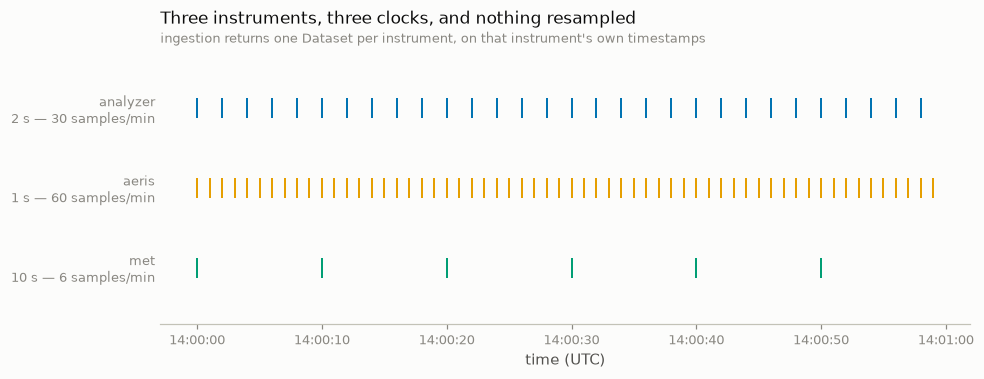

In [19]:
analyzer, aeris, met = streams["analyzer"], streams["aeris"], streams["met"]
start = pd.Timestamp(analyzer["time"].values[0])
stop = start + pd.Timedelta("1min")
rows = [("analyzer", analyzer, C1, 2.0), ("aeris", aeris, C2, 1.0), ("met", met, C3, 0.0)]

fig, ax = plt.subplots(figsize=(9.5, 3.2))
labels = []
for name, stream, colour, height in rows:
    clock = stream["time"].values
    inside = (clock >= np.datetime64(start)) & (clock < np.datetime64(stop))
    ax.plot(clock[inside], np.full(int(inside.sum()), height), "|", color=colour, ms=13, mew=1.3)
    labels.append(f"{name}\n{median_interval(stream):.0f} s — {int(inside.sum())} samples/min")
ax.set_ylim(-0.7, 2.7)
ax.set_yticks([0.0, 1.0, 2.0])
ax.set_yticklabels(labels[::-1])
ax.tick_params(axis="y", length=0, labelsize=8.5)
ax.spines["left"].set_visible(False)
finish(
    ax,
    "Three instruments, three clocks, and nothing resampled",
    "ingestion returns one Dataset per instrument, on that instrument's own timestamps",
    None,
    "time (UTC)",
    grid_axis=None,
)
hhmm(ax, "%H:%M:%S")
plt.show()

"Synchronize late" is the decision this enforces (`docs/METHODS.md` §1.1).
Baselines and detection run per species at native rate, because a plume event is
a *time interval* and therefore rate-agnostic; cross-species pairing happens on
the wider-supported stream's cells, with its partner bin-averaged onto them.
never interpolated. Interpolating a 10 s stream up to 2 s would manufacture
five times as many "measurements" as were made, and a regression fitted to them
would report a confidence interval far tighter than the data can support.

### Two instruments, one gas

The analyzer and the aeris are pointed at the same air and both report methane.
They stay two variables for the whole life of the pipeline, because each lives in
its own instrument's stream: a variable is identified by its instrument and its
name together. What they measure is recorded separately, and the manifest
printed in §2 shows it: the aeris's variable is called `aeris_ch4` and declares
`field: ch4`, and ingestion writes that into the variable's `field` attribute.
The names would not have to differ. A manifest may call both records `ch4`,
since a name only has to be unique within one instrument, and a later stage
that joins them asks which instrument is meant rather than picking one
(`docs/METHODS.md` §1.6).

That separation is the whole point. The interesting question about two methane
instruments on one platform — do they agree, and where do they diverge? — only
exists for as long as they remain two variables. A pipeline that merged them
would have answered it before the data was loaded, silently, by whichever one
happened to be assembled last.

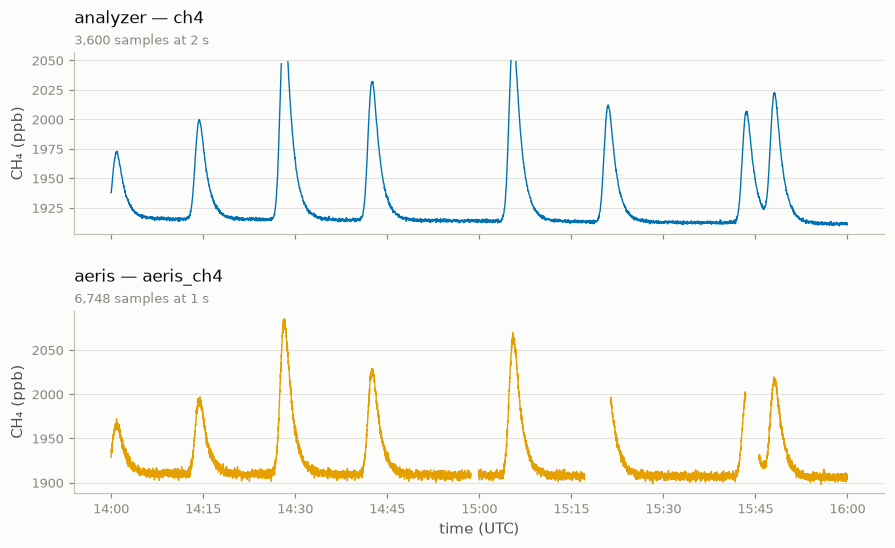

aeris    : 3 outages, longest 4.2 min
analyzer : 0 irregular steps — its logger never stopped


In [20]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 5.2), sharex=True, gridspec_kw={"hspace": 0.42})

for ax, (name, variable, colour) in zip(
    axes, [("analyzer", "ch4", C1), ("aeris", "aeris_ch4", C2)]
):
    stream = streams[name]
    # Drawn on gap-broken copies: the aeris logger drops out, and a line ruled
    # across an outage would assert measurements that were never made.
    clock, values = break_gaps(stream["time"].values, stream[variable].values)
    ax.plot(clock, values, color=colour, lw=0.9)
    finish(
        ax,
        f"{name} — {variable}",
        f"{stream.sizes['time']:,} samples at {median_interval(stream):.0f} s",
        "CH₄ (ppb)",
    )
axes[1].set_xlabel("time (UTC)")
hhmm(axes[1])
plt.show()

gaps = np.diff(streams["aeris"]["time"].values).astype("timedelta64[s]").astype(float)
outages = gaps[gaps > 5 * np.median(gaps)]
steady = np.diff(streams["analyzer"]["time"].values) != np.timedelta64(2, "s")
print(f"aeris    : {outages.size} outages, longest {outages.max() / 60:.1f} min")
print(f"analyzer : {int(steady.sum())} irregular steps — its logger never stopped")

Drawn as two panels rather than two lines on one axis, because they are two
measurements and a shared axis would quietly imply they are one. They track each
other — the same air, so the same background and the same plumes — and
they are not the same record: different noise, and a clock that runs at half
the interval and stops occasionally.

The clipped peaks are the second thing worth seeing, and they are not a
plotting artifact. The analyzer declares a QA/QC ceiling at 2050 ppb and the
aeris declares none, so the same plumes arrive intact in one record and with
their tops masked out of the other. Neither instrument is wrong: §5's rule is
that a QA/QC bound is a statement about *the instrument*, never about the air,
and two instruments genuinely do saturate at different places. What it costs is
visible here in a way a single record cannot show — the enhancement TSARA exists
to measure survives on one clock and not the other, which is a fact Phase 4
needs to know before it pairs them.

Those holes are the third thing worth seeing. The aeris logger drops rows
rather than writing NaN, which is what an outage actually looks like on disk, so
its native clock is genuinely irregular. Ingestion neither fills nor flags them:
a gap in the timestamps *is* the record of an outage, and it stays legible to
every later phase precisely because nothing was resampled onto a tidy grid. The
figure has to be told, though — matplotlib rules a straight line across a hole,
which is why `break_gaps` above lifts the pen. Drawing it the other way would
put an interpolation on the page that the pipeline itself refuses to perform.

---
## 10. Mobile platforms, and a boundary ingestion will not cross

A mobile campaign's position is a timeseries, not a constant — and it lives on
the GPS instrument's clock, not on the gas analyzer's. So it arrives as its own
stream, which is the canonical multi-rate case.

In [21]:
mobile_spec = {
    **SPEC,
    "name": "mobile_demo",
    "seed": 5,
    "duration": "40min",
    "platform": {
        "kind": "mobile",
        "gps_instrument": "gps",
        "gps_rate": "1s",
        "start_latitude": 40.77,
        "start_longitude": -111.89,
        "speed_m_s": 12.0,
        "pattern": "random_walk",
        "heading_volatility": 0.06,
    },
}
mobile_manifest = export_raw(generate(SyntheticConfig.model_validate(mobile_spec)), WORK / "mobile")
mobile = ingest_campaign(load_manifest(mobile_manifest))

print("streams:", sorted(mobile.streams))
print()
print("gas stream coordinates :", list(mobile["analyzer"].coords))
print("gps stream variables   :", sorted(mobile["gps"].data_vars))
print()
print("what the gas stream records about the platform instead:")
for key, value in mobile["analyzer"].attrs.items():
    if key.startswith("platform"):
        print(f"   {key:28} {value}")

2026-09-23 12:15:19 | INFO     | tsara.synthetic.generator | Scheduled 4 plume events (4 top-level, 0 nested) across 1 sources.


2026-09-23 12:15:19 | INFO     | tsara.synthetic.generator | Generated 4 streams with 12 ground-truth rows.


2026-09-23 12:15:19 | INFO     | tsara.synthetic.export | Exported 4 synthetic stream(s) as raw CSV to <work>/mobile/raw with manifest <work>/mobile/manifest.yaml.


2026-09-23 12:15:19 | INFO     | tsara.config.loader | Loaded manifest 'mobile_demo': 4 instrument(s), 2 gas species, platform=mobile


2026-09-23 12:15:19 | INFO     | tsara.ingest.campaign | Ingesting instrument 'analyzer'.


...

2026-09-23 12:15:19 | INFO     | tsara.ingest.campaign | Ingesting instrument 'met'.


2026-09-23 12:15:19 | INFO     | tsara.ingest.campaign | Instrument 'met': 240 samples from 1 file(s).


2026-09-23 12:15:19 | INFO     | tsara.ingest.campaign | Ingesting instrument 'gps'.


2026-09-23 12:15:19 | INFO     | tsara.ingest.campaign | Instrument 'gps': 2400 samples from 1 file(s).


streams: ['aeris', 'analyzer', 'gps', 'met']

gas stream coordinates : ['time', 'time_bnds']
gps stream variables   : ['latitude', 'longitude']

what the gas stream records about the platform instead:
   platform_kind                mobile
   platform_gps_instrument      gps
   platform_lat_variable        latitude
   platform_lon_variable        longitude


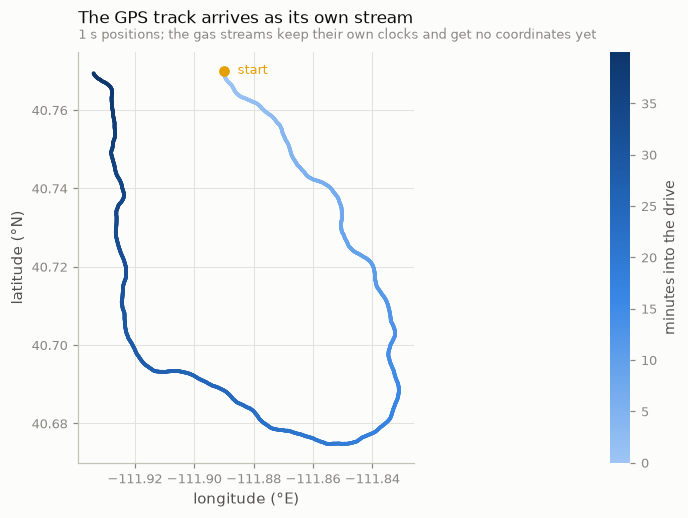

In [22]:
gps = mobile["gps"]
longitude, latitude = gps["longitude"].values, gps["latitude"].values
minutes = (gps["time"].values - gps["time"].values[0]) / np.timedelta64(1, "m")

fig, ax = plt.subplots(figsize=(8.6, 4.6), layout="constrained")
points = ax.scatter(longitude, latitude, c=minutes, cmap=TRACK, s=6, linewidths=0)
ax.plot(longitude[0], latitude[0], "o", color=C2, ms=6, zorder=3)
ax.annotate(
    "start",
    (longitude[0], latitude[0]),
    textcoords="offset points",
    xytext=(9, -2),
    color=C2,
    fontsize=8.5,
)
bar = fig.colorbar(points, ax=ax, pad=0.02)
bar.set_label("minutes into the drive", fontsize=9, color=INK2)
bar.outline.set_visible(False)
# One degree of longitude is shorter than one of latitude at this latitude, so
# an equal-degree aspect would stretch the track east-west.
ax.set_aspect(1.0 / np.cos(np.deg2rad(float(np.mean(latitude)))))
ax.ticklabel_format(useOffset=False, style="plain", axis="both")
finish(
    ax,
    "The GPS track arrives as its own stream",
    "1 s positions; the gas streams keep their own clocks and get no coordinates yet",
    "latitude (°N)",
    "longitude (°E)",
    grid_axis="both",
)
plt.show()

Notice what this figure **cannot** show: the methane. Colouring this track by
concentration would require putting the GPS position onto the analyzer's
timestamps, and that is interpolation — permitted for smooth auxiliary fields
like position, but only under a `max_interp_gap` guard that says how long a GPS
outage may be before the join is refused. That guard lives in `AlignmentConfig`,
a **Phase 4** object which ingestion has no business reading.

So ingestion loads GPS as an ordinary stream, records the binding in attrs
(`platform_gps_instrument`, `platform_lat_variable`, `platform_lon_variable`),
and stops. The interpolation rule then stays enforced in exactly one place
instead of two. A stationary platform gets its coordinates here because there is
no interpolation involved: one position, applied globally.

---
## 11. Persistence

Streams save as a **TSARA bundle** — a directory, not a file, and the same
layout Phase 2 introduced, extended rather than replaced:

```
<bundle>/
    bundle.json      contents, format version, and which stage wrote it
    manifest.yaml    the resolved configuration that produced these streams
    streams/
        <instrument>.nc
```

Every stage product gains save/load **in the phase that introduces it**, which
is what makes intermediates inspectable in a notebook, lets a long cluster run
resume after a crash, and keeps a result reproducible without its original
archive.

In [23]:
bundle = save_streams(streams, WORK / "ingest_bundle")

for path in sorted(bundle.rglob("*")):
    if path.is_file():
        show(f"   {path.relative_to(bundle).as_posix():<24} {path.stat().st_size / 1024:8.1f} KB")

print()
print("bundle.json:")
print(json.dumps(json.loads((bundle / "bundle.json").read_text()), indent=2))

reloaded = load_streams(bundle)
identical = all(
    np.array_equal(reloaded[name][variable].values, stream[variable].values, equal_nan=True)
    for name, stream in streams.streams.items()
    for variable in stream.data_vars
)
print()
print(f"every variable identical after a round trip through netCDF : {identical}")
print(
    f"manifest identical                                         : "
    f"{reloaded.manifest == streams.manifest}"
)

2026-09-23 12:15:20 | INFO     | tsara.ingest.bundle | Wrote ingest bundle to <work>/ingest_bundle (3 streams).


2026-09-23 12:15:20 | INFO     | tsara.ingest.bundle | Loaded ingest bundle from <work>/ingest_bundle (3 streams).


   bundle.json                   0.2 KB
   manifest.yaml                 3.6 KB
   streams/aeris.nc            282.2 KB
   streams/analyzer.nc         253.5 KB
   streams/met.nc               36.5 KB

bundle.json:
{
  "bundle_format_version": 3,
  "tsara_version": "0.1.0",
  "stage": "ingest",
  "campaign": "ingest_demo",
  "streams": [
    "aeris",
    "analyzer",
    "met"
  ]
}

every variable identical after a round trip through netCDF : True
manifest identical                                         : True


The `stage` key is what distinguishes this from a synthetic bundle. Both are a
`bundle.json` at format version 1 beside a `streams/` directory, so the skeleton
alone cannot tell them apart — and a synthetic file mistaken for a measurement
is a scientific hazard. netCDF4 for the streams because it is the atmospheric
community's standard and xarray round-trips it losslessly, attrs and coordinates
included.

---
## 12. The ledger — what ingestion does, and what it deliberately will not

| | |
|---|---|
| Find files across several directory layouts | **yes** — a list of path templates per instrument, plus `exclude` |
| Harvest metadata from the path | **yes** — `{field}` placeholders become per-file metadata |
| Parse CSV, ICARTT, parquet | **yes** — a name-dispatched reader registry; new formats are new modules |
| Rename columns to canonical names | **yes** — in the manifest, never in a reader |
| Convert units | **yes** — declared scale and offset, applied before anything else |
| Mask bad samples | **yes** — `range` and `flag` rules, masking not deleting, counted per rule |
| Resolve declared and reported uncertainty | **yes** — both components, kept separate, provenance labelled |
| Reject statistical outliers | **no** — there is no spike rule; a 1–2 sample excursion is what a plume looks like |
| Estimate noise from the data | **no** — labelled `empirical`; the estimator belongs to a later phase |
| Resample or align anything | **no** — streams stay at native rate (Phase 4) |
| Attach GPS to a gas stream | **no** — that is interpolation, and its guard lives in Phase 4 |
| Accept or reject whole files on quality | **no** — an open design flag; today `exclude` is the mechanism |
| Integrate plume areas | **no** — deferred as a future avenue (`docs/METHODS.md` §7) |

**What this ran on, and what it was learned from.** Everything above is
manufactured, and deliberately so — it is the only way the answers can be
checked. The same code path, unchanged, reads the campaign archive this package
was built for: **all 1122 ICARTT files parse, yielding 35,275,729 rows**, up
from 1054 files and 30,190,402 rows when this phase began. Along the way it
masks **23.8 million** limit-of-detection sentinels — 10.03% of every numeric
value in that archive — which before this phase were reaching canonical units as
real numbers, with the consequence §8 shows in miniature. Those measurements,
and the decisions each one settled, are in `docs/METHODS.md` §9.

### Where to read further

- `docs/METHODS.md` §9 — the mathematics, the measurements, and the rejected
  alternatives for everything above, including what the real archive taught each
  decision.
- `examples/configs/manifest_multiformat_example.yaml` — one campaign whose
  three instruments use all three readers, with comments on every field.
- `examples/notebooks/01_synthetic_data_walkthrough.ipynb` — where the data
  above came from, and why synthetic truth is the only arbiter available.
- `examples/configs/manifest_multiformat_example.yaml` again, as a starting
  point: the fastest way to describe your own archive is to copy the instrument
  block whose reader matches yours and change the column names.

**Next phase.** Phase 4 takes these native-rate streams and pairs them: gases
Gases are binned onto those cells with the two uncertainty components
propagated by different algebra, auxiliary fields interpolated under an explicit
gap guard, circular statistics for wind direction, and one master output grid
built only for the continuous rolling state and the PMF export matrix.